# CNASim Benchmark

This notebook analyses the results of the experiments.

In [30]:
import os

import scgenome.plotting as pl
import seaborn as sns
import matplotlib.pyplot as plt
import anndata
from Bio import Phylo
from io import StringIO
import pandas as pd

from cellmates.utils.tree_utils import make_gt_tree_dist

In [8]:
# input = snakemake.input[0]
input = "../../results/stats.csv"

In [37]:
stats_df = pd.read_csv(input)
stats_df['noise'] = stats_df['dataset'].map(lambda x: x[-1])
stats_df.describe()

,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,uw_mse,rf,urf,nrf,f1_gt,f1_em,cn_mad
count,40.00000,40.000000,40.0,40.0,40.0,40.0,40.000000,4.000000e+01,4.000000e+01,40.000000,40.000000,40.000000,40.0,40.0,0.0
mean,2.00000,17.500000,7.0,1.0,2879.0,2.0,0.000005,4.772145e-08,9.216101e-08,0.981650,5.200000,0.149728,1.0,1.0,NaN
std,1.43223,7.595545,0.0,0.0,0.0,0.0,0.000002,4.088341e-08,9.462331e-08,1.560598,5.393253,0.125830,0.0,0.0,NaN
min,0.00000,10.000000,7.0,1.0,2879.0,2.0,0.000002,2.833897e-09,2.713729e-09,0.003230,0.000000,0.000000,1.0,1.0,NaN
25%,1.00000,10.000000,7.0,1.0,2879.0,2.0,0.000003,1.224101e-08,1.603276e-08,0.006031,2.000000,0.043478,1.0,1.0,NaN
50%,2.00000,17.500000,7.0,1.0,2879.0,2.0,0.000005,2.992217e-08,5.374135e-08,0.008384,4.000000,0.125000,1.0,1.0,NaN
75%,3.00000,25.000000,7.0,1.0,2879.0,2.0,0.000007,8.246464e-08,1.434289e-07,1.258282,8.000000,0.250000,1.0,1.0,NaN
max,4.00000,25.000000,7.0,1.0,2879.0,2.0,0.000009,1.302164e-07,3.394916e-07,5.007114,20.000000,0.434783,1.0,1.0,NaN


In [38]:
stats_df.head()

,dat_path,dataset,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,...,rf,urf,nrf,f1_gt,f1_em,wgd,gt_ties,data_type,cn_mad,noise
0,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,A1_0,0,10,7,1,2879,2.0,0.000005,1.545469e-08,...,0.005477,4,0.250,1.0,1.0,False,True,reads,NaN,0
1,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,A1_0,0,10,7,1,2879,2.0,0.000002,4.997862e-08,...,0.003633,4,0.250,1.0,1.0,False,True,cn,NaN,0
2,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,A1_0,1,10,7,1,2879,2.0,0.000007,2.833897e-09,...,0.005914,2,0.125,1.0,1.0,False,True,reads,NaN,0
3,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,A1_0,1,10,7,1,2879,2.0,0.000002,3.138401e-08,...,0.004371,2,0.125,1.0,1.0,False,True,cn,NaN,0
4,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,A1_0,2,10,7,1,2879,2.0,0.000008,4.803819e-08,...,0.007593,4,0.250,1.0,1.0,False,True,reads,NaN,0


## Data plots
Plot CN, trees, reads to verify the quality and complexity of the data.

### Small tree
#### Data

In [13]:
min_n_cells = stats_df['n_cells'].min()
# dat_dir = os.path.join('../../', os.path.dirname(stats_df[stats_df['n_cells'] == min_n_cells]['dat_path'].iloc[0]))
dat_dir = os.path.dirname(stats_df[stats_df['n_cells'] == min_n_cells]['dat_path'].iloc[0])
dat_dir

'../../results/data/R1_N10_M100_K2_L2_E10.04_E20.1_C2'

In [17]:
# plot example
adata = anndata.read_h5ad(os.path.join(dat_dir, "input.h5ad"))
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
# use tree from cn-derived branch lengths
cell_names = adata[~adata.obs['normal']].obs_names.tolist()
dpy_tree, gt_ctr = make_gt_tree_dist(adata, n_states=7, cell_names=cell_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = cell_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick')
adata

AnnData object with n_obs × n_vars = 10 × 100
    obs: 'normal', 'clone'
    var: 'chr', 'start', 'end'
    uns: 'ancestral-cn', 'ancestral-cnA', 'ancestral-cnB', 'ancestral-names', 'cell-tree-newick', 'clonal-tree-newick', 'clone-id-tree-newick', 'cnasim-params'
    layers: 'Acopy', 'Acount', 'Astate', 'Bcopy', 'Bcount', 'Bstate', 'copy', 'state'

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


Text(0.5, 0.98, 'Target (GT)')

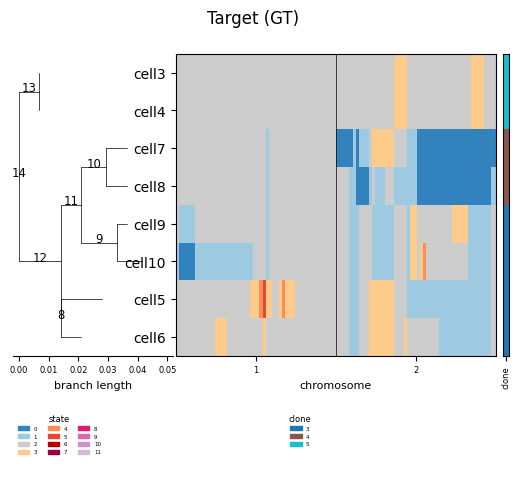

In [22]:
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=bio_tree_cn_lengths, annotation_fields=['clone'], show_cell_ids=True)
g['fig'].suptitle('Target (GT)');

Text(0.5, 0.98, 'Observation (GT) - with normal cells')

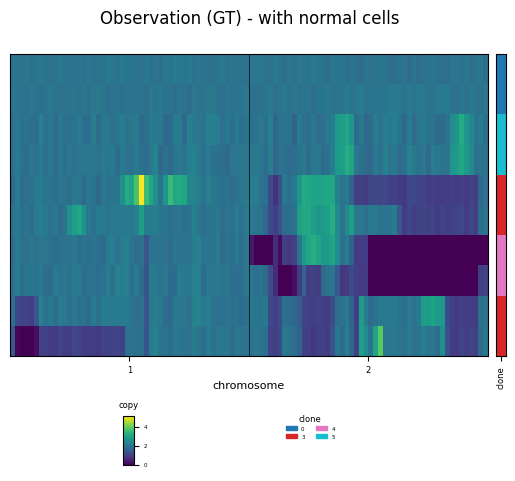

In [58]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', annotation_fields=['clone'], raw=True)
g['fig'].suptitle('Observation (GT) - with normal cells');

#### Inferred

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


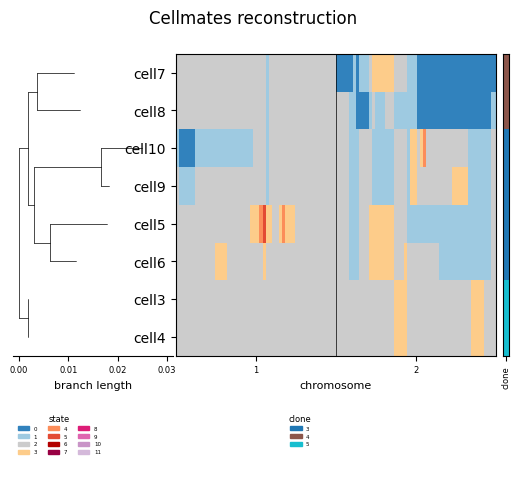

In [25]:
em_nwk = open(os.path.join(dat_dir, "cm_out", "tree.nwk")).read()
inferred_tree = Phylo.read(os.path.join(dat_dir, "cm_out", "tree.nwk"), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=inferred_tree, annotation_fields=['clone'], show_cell_ids=True)
g['fig'].suptitle('Cellmates reconstruction');

# Benchmarks

## Robinson Fould

In [39]:
# place rf, urf, nrf in same col 'metric'
rf_melt = pd.melt(stats_df,
                  id_vars=['n_cells', 'noise', 'data_type'],
                  value_vars=['rf', 'urf', 'nrf'],
                  var_name='metric',
                  value_name='value'
                  )
rf_melt.head()

,n_cells,noise,data_type,metric,value
0,10,0,reads,rf,0.005477
1,10,0,cn,rf,0.003633
2,10,0,reads,rf,0.005914
3,10,0,cn,rf,0.004371
4,10,0,reads,rf,0.007593


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarnin

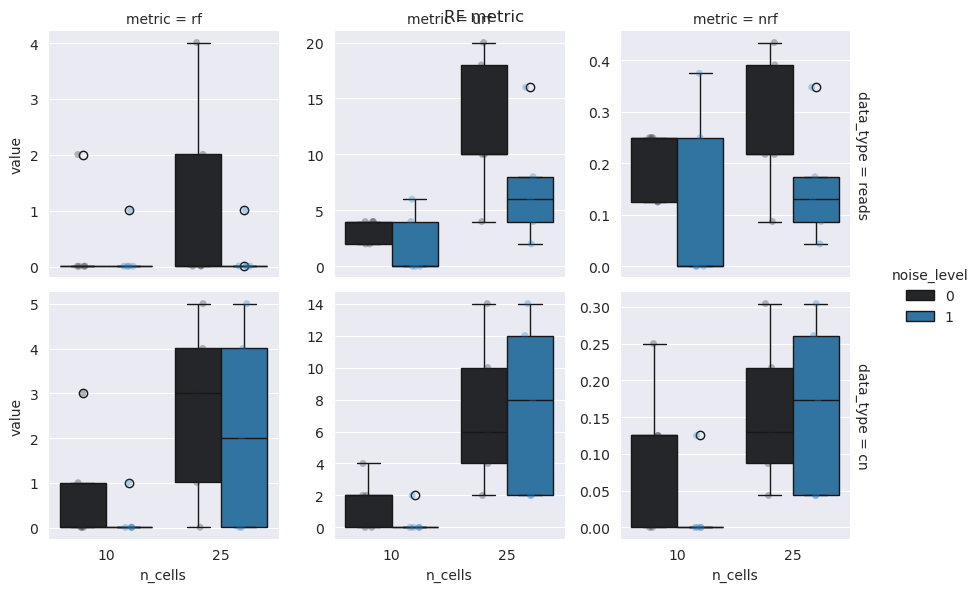

In [58]:
# plot RF distance
g = sns.FacetGrid(rf_melt, row='data_type', col='metric', margin_titles=True, sharey=False)
g.map_dataframe(sns.boxplot, x='n_cells', y='value', hue='noise', dodge=True)
g.map_dataframe(sns.stripplot, x='n_cells', y='value', hue='noise',
                dodge=True, alpha=0.3, legend=False)
g.add_legend(title='noise_level')
g.fig.suptitle('RF metric');

## F1 metric (against GT)

In [46]:
f1_melt = pd.melt(stats_df,
                  id_vars=['n_cells', 'noise', 'seed', 'data_type'],
                  value_vars=['f1_gt', 'f1_em'],
                  var_name='metric',
                  value_name='value'
                  )
f1_melt.head()


,n_cells,noise,seed,data_type,metric,value
0,10,0,0,reads,f1_gt,1.0
1,10,0,0,cn,f1_gt,1.0
2,10,0,1,reads,f1_gt,1.0
3,10,0,1,cn,f1_gt,1.0
4,10,0,2,reads,f1_gt,1.0


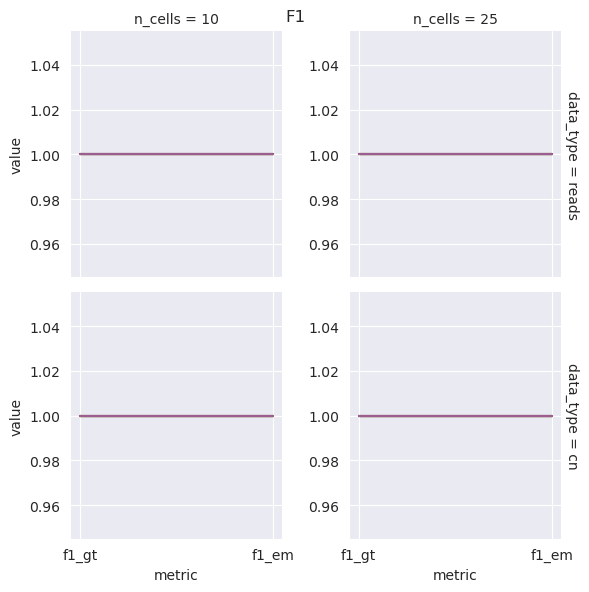

In [48]:
g = sns.FacetGrid(f1_melt, row='data_type', col='n_cells', margin_titles=True, sharey=False, hue='seed')
g.map(sns.lineplot, 'metric', 'value', alpha=0.7, markers=True)
g.fig.suptitle('F1');


## Branch lengths error

In [51]:
err_melt = pd.melt(stats_df,
                  id_vars=['n_cells', 'data_type', 'noise'],
                  value_vars=['ru_mse', 'uv_mse', 'uw_mse'],
                  var_name='metric',
                  value_name='value'
                  )
err_melt.head()

,n_cells,data_type,noise,metric,value
0,10,reads,0,ru_mse,0.000005
1,10,cn,0,ru_mse,0.000002
2,10,reads,0,ru_mse,0.000007
3,10,cn,0,ru_mse,0.000002
4,10,reads,0,ru_mse,0.000008


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


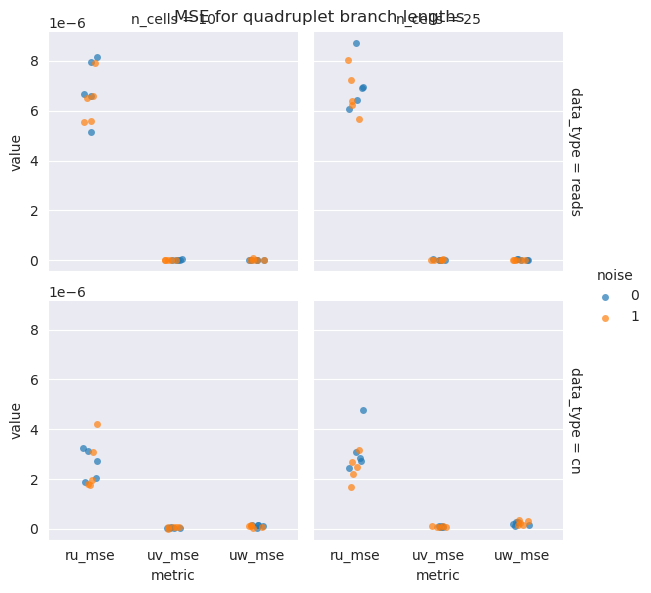

In [59]:
g = sns.FacetGrid(err_melt, row='data_type', col='n_cells', hue='noise', margin_titles=True, sharey=True)
g.map(sns.stripplot, 'metric', 'value', alpha=0.7, dodge=True)
g.add_legend(title='noise')
g.fig.suptitle('MSE for quadruplet branch lengths');